In [1]:
%load_ext autoreload
%autoreload 2

# Preamble

In [2]:
import secrets
import time
from random import randint

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from fastecdsa.curve import P256

In [3]:
N_KEYS = 20
N_SAMPLES = 500

MIN_MSB = 1
MAX_MSB = 255

CURVE = P256
MSG = b"timing experiment"
K = randint(1, CURVE.q).to_bytes(32, "little")

# Function Definitions

In [4]:
def generate_key_with_msb(msb: int, bits: int = 256) -> bytes:
    if not 0 <= msb < bits:
        raise ValueError("invalid MSB")

    d = (1 << msb) | secrets.randbits(msb)
    return d.to_bytes(32, "little")


def generate_key_with_weight(weight: int, bits: int = 256) -> bytes:
    if not 1 <= weight <= bits:
        raise ValueError("invalid Hamming weight")

    positions = secrets.SystemRandom().sample(range(bits), weight)

    d = 0
    for pos in positions:
        d |= 1 << pos

    return d.to_bytes(32, "little")


def benchmark(experiments, sign, msg, k, samples_per_key=500):
    # Randomize the complete experiment order.
    experiments = list(experiments)
    secrets.SystemRandom().shuffle(experiments)

    # Warmup.
    for _, d in experiments[:100]:
        sign(msg, d, k)

    results = []

    for property_value, d in experiments:
        for _ in range(samples_per_key):
            t0 = time.perf_counter_ns()
            sign(msg, d, k)
            t1 = time.perf_counter_ns()

            results.append(
                (
                    property_value,
                    d,
                    t1 - t0,
                )
            )

    return results


def trim_times(times, low=0.01, high=0.99):
    lo, hi = np.quantile(times, [low, high])
    mask = (times >= lo) & (times <= hi)
    return times[mask], mask


def timing_heatmap(
    x,
    times,
    xlabel,
    title,
    window=500,
    bin_width=100,
):
    center = round(np.median(times) / bin_width) * bin_width

    y_edges = np.arange(
        center - window,
        center + window + bin_width,
        bin_width,
    )

    x_min = np.min(x)
    x_max = np.max(x)

    x_edges = np.arange(
        x_min - 0.5,
        x_max + 1.5,
        1,
    )

    plt.figure(figsize=(14, 8))

    plt.hist2d(
        x,
        times,
        bins=[x_edges, y_edges],
    )

    plt.xlabel(xlabel)
    plt.ylabel("Runtime (ns)")
    plt.title(title)

    plt.ylim(center - window, center + window)

    plt.colorbar(label="Observations")

    plt.show()


def quantile_plot(x, times, xlabel, title):
    values = np.unique(x)

    p10 = []
    p50 = []
    p90 = []

    for value in values:
        t = times[x == value]

        p10.append(np.percentile(t, 10))
        p50.append(np.percentile(t, 50))
        p90.append(np.percentile(t, 90))

    p10 = np.array(p10)
    p50 = np.array(p50)
    p90 = np.array(p90)

    plt.figure(figsize=(14, 5))

    plt.fill_between(
        values,
        p10,
        p90,
        alpha=0.25,
        label="10–90 percentile",
    )

    plt.plot(
        values,
        p50,
        label="Median",
    )

    plt.xlabel(xlabel)
    plt.ylabel("Runtime (ns)")
    plt.title(title)
    plt.legend()

    plt.show()


def correlation_analysis(x, times):
    pearson = stats.pearsonr(x, times)
    spearman = stats.spearmanr(x, times)

    print("Pearson:")
    print(f"  r = {pearson.statistic:.6f}")
    print(f"  p = {pearson.pvalue:.6e}")

    print()
    print("Spearman:")
    print(f"  rho = {spearman.statistic:.6f}")
    print(f"  p = {spearman.pvalue:.6e}")


def regression_analysis(x, times):
    result = stats.linregress(x, times)

    print()
    print(f"slope:     {result.slope:.4f} ns / unit")
    print(f"intercept: {result.intercept:.2f} ns")
    print(f"r:         {result.rvalue:.6f}")
    print(f"R²:        {result.rvalue**2:.6f}")
    print(f"p-value:   {result.pvalue:.6e}")
    print(f"stderr:    {result.stderr:.4f} ns / unit")


def residual_plot(x, times, xlabel, title):
    median = np.median(times)
    residual = times - median

    plt.figure(figsize=(14, 5))

    plt.scatter(
        x,
        residual,
        s=2,
        alpha=0.15,
    )

    plt.axhline(0, linewidth=1)

    plt.xlabel(xlabel)
    plt.ylabel("Runtime − global median (ns)")
    plt.title(title)

    plt.show()

# Most Significant Bit Analysis

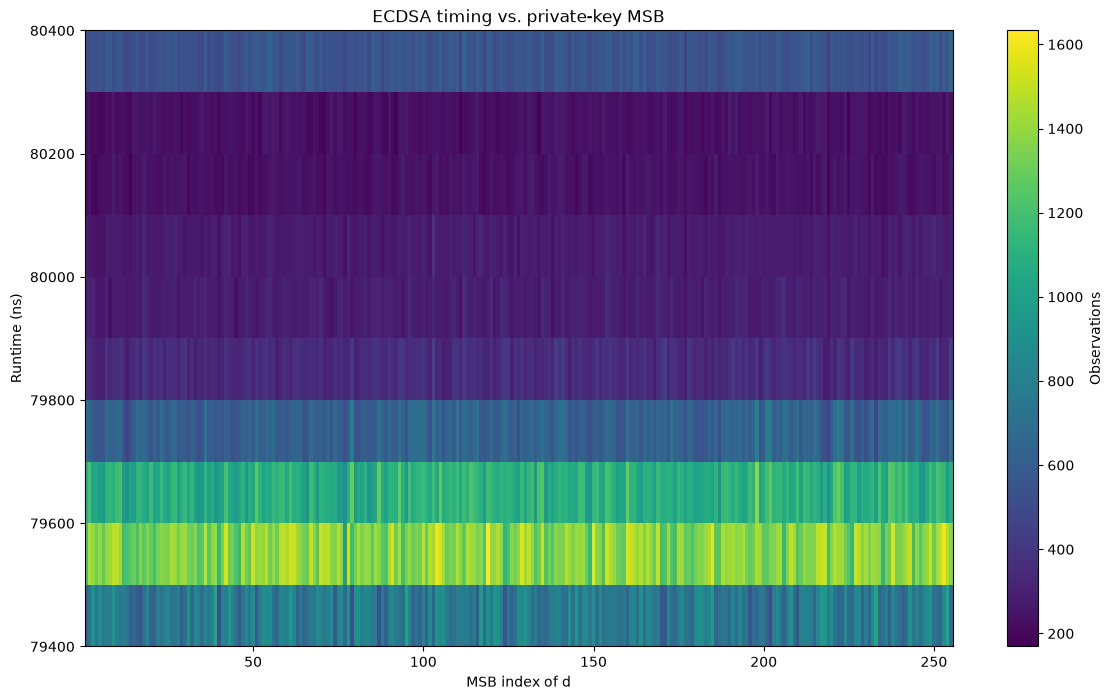

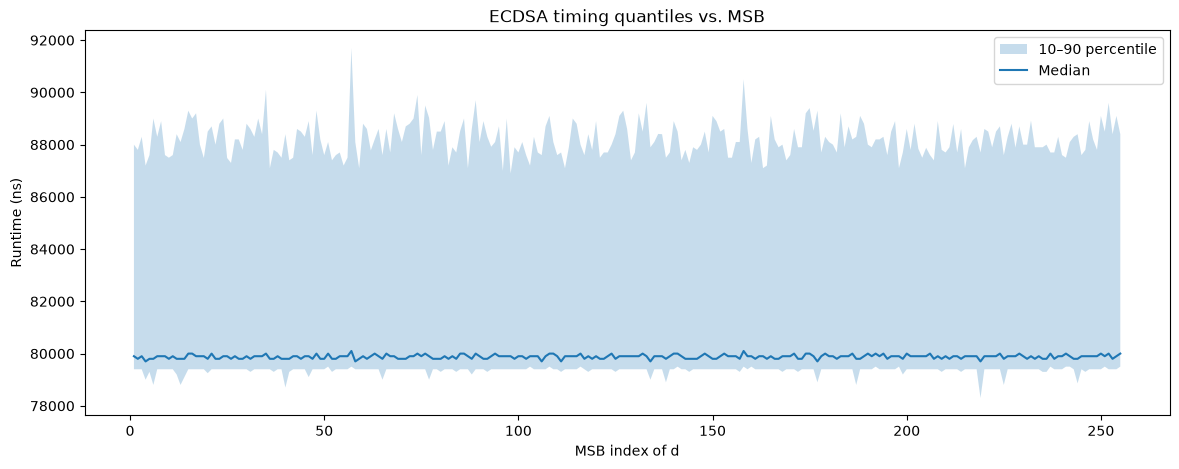

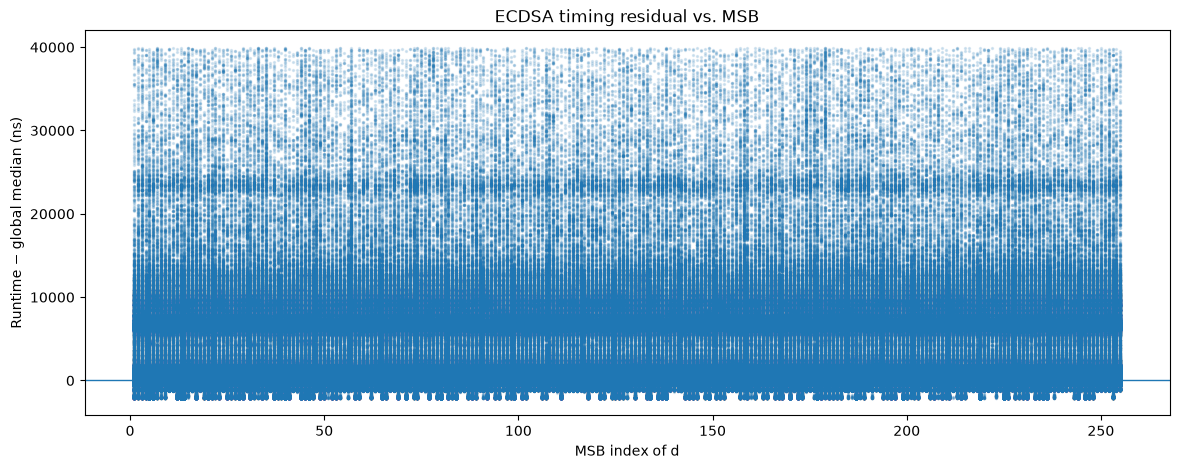

Pearson:
  r = 0.000765
  p = 2.248846e-01

Spearman:
  rho = 0.008298
  p = 1.572299e-39

slope:     0.0540 ns / unit
intercept: 82100.73 ns
r:         0.000765
R²:        0.000001
p-value:   2.248846e-01
stderr:    0.0445 ns / unit


In [5]:
msb_experiments = [
    (msb, generate_key_with_msb(msb))
    for msb in range(MIN_MSB, MAX_MSB + 1)
    for _ in range(N_KEYS)
]

results_msb = benchmark(
    msb_experiments,
    CURVE.sign,
    MSG,
    K,
    samples_per_key=N_SAMPLES,
)

msb = np.array([r[0] for r in results_msb])
d_msb = np.array([r[1] for r in results_msb], dtype=object)
times_msb = np.array([r[2] for r in results_msb])

times_msb_trimmed, mask_msb = trim_times(times_msb)
msb_trimmed = msb[mask_msb]

timing_heatmap(
    msb_trimmed,
    times_msb_trimmed,
    "MSB index of d",
    "ECDSA timing vs. private-key MSB",
)

quantile_plot(
    msb_trimmed,
    times_msb_trimmed,
    "MSB index of d",
    "ECDSA timing quantiles vs. MSB",
)

residual_plot(
    msb_trimmed,
    times_msb_trimmed,
    "MSB index of d",
    "ECDSA timing residual vs. MSB",
)


correlation_analysis(
    msb_trimmed,
    times_msb_trimmed,
)

regression_analysis(
    msb_trimmed,
    times_msb_trimmed,
)

# Hamming Weight Analysis

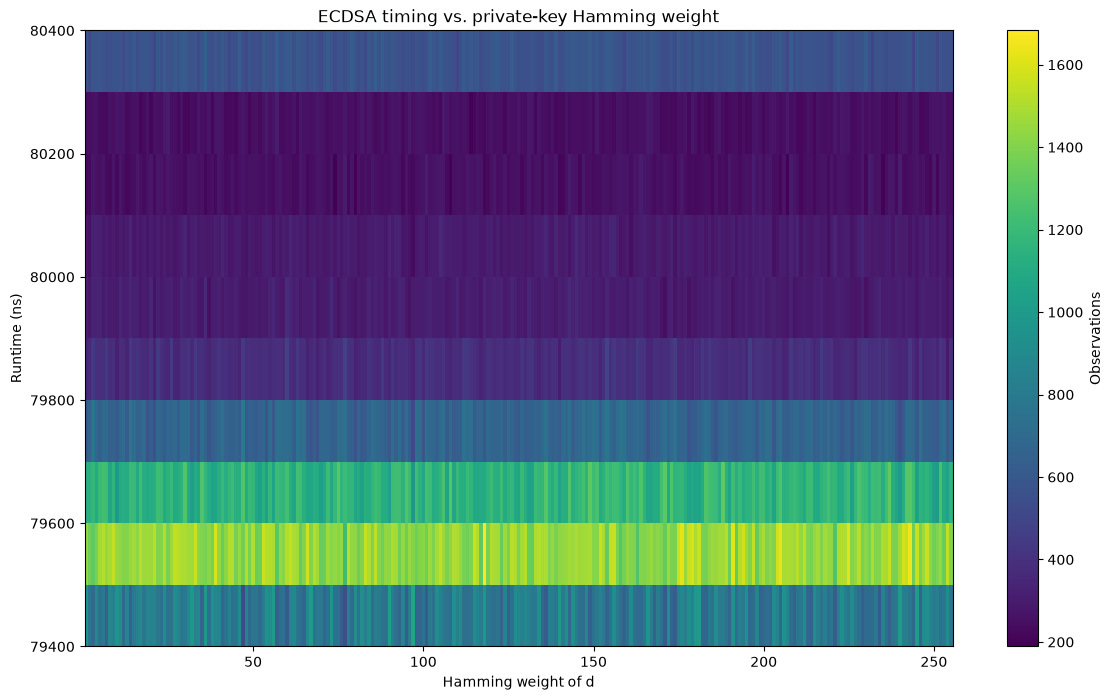

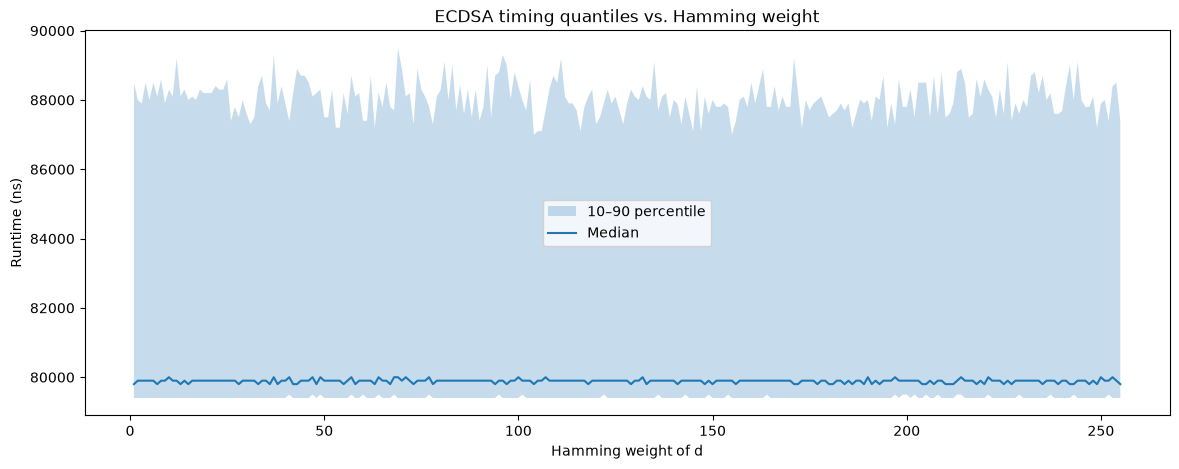

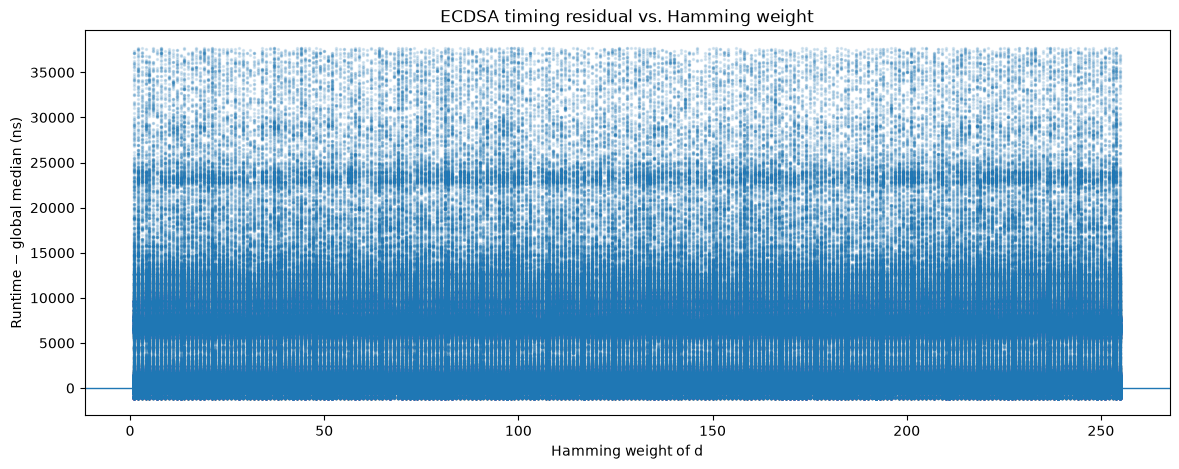

Pearson:
  r = -0.001226
  p = 5.200179e-02

Spearman:
  rho = -0.000103
  p = 8.697654e-01

slope:     -0.0828 ns / unit
intercept: 82105.52 ns
r:         -0.001226
R²:        0.000002
p-value:   5.200179e-02
stderr:    0.0426 ns / unit


In [6]:
hw_experiments = [
    (hw, generate_key_with_weight(hw)) for hw in range(1, 256) for _ in range(N_KEYS)
]

results_hw = benchmark(
    hw_experiments,
    CURVE.sign,
    MSG,
    K,
    samples_per_key=N_SAMPLES,
)

hw = np.array([r[0] for r in results_hw])
d_hw = np.array([r[1] for r in results_hw], dtype=object)
times_hw = np.array([r[2] for r in results_hw])

times_hw_trimmed, mask_hw = trim_times(times_hw)
hw_trimmed = hw[mask_hw]

timing_heatmap(
    hw_trimmed,
    times_hw_trimmed,
    "Hamming weight of d",
    "ECDSA timing vs. private-key Hamming weight",
)

quantile_plot(
    hw_trimmed,
    times_hw_trimmed,
    "Hamming weight of d",
    "ECDSA timing quantiles vs. Hamming weight",
)

residual_plot(
    hw_trimmed,
    times_hw_trimmed,
    "Hamming weight of d",
    "ECDSA timing residual vs. Hamming weight",
)

correlation_analysis(
    hw_trimmed,
    times_hw_trimmed,
)

regression_analysis(
    hw_trimmed,
    times_hw_trimmed,
)